## Minería de flujos - Count-Min Sketch

Se estima con un **Count-Min Sketch** cuántas veces aparece cada par entidad-proveedor

### Imports

In [1]:
import os, socket, sys, math, time, hashlib
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
in_dir = proyecto / "04_Flujos" / "temp" / "a_dgim"
out_dir = proyecto / "04_Flujos" / "temp" / "c_sketch"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

- Figuras y tablas

In [3]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

- Spark

In [4]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("flujos-sketch")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [5]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Carga del flujo

Se lee el flujo ordenado de `temp/a_dgim/flujo`

In [6]:
assert (in_dir / "flujo").exists(), "Corre a_dgim.ipynb (Run All) antes que este notebook."

flujo_pd = (spark.read.parquet(str(in_dir / "flujo"))
            .where("proveedor IS NOT NULL")
            .select("t", "fecha", "anio", "mes", "entidad", "proveedor", "postor_unico")
            .orderBy("t").toPandas())
pares = (flujo_pd["entidad"] + "|" + flujo_pd["proveedor"]).tolist()

L = len(pares)
n = len(set(pares))
print(f"Llegadas con proveedor (L): {L:,} | pares entidad-proveedor distintos (n): {n:,}")
print(f"Llegadas que repiten un par ya visto: {L - n:,} ({100 * (L - n) / L:.1f}%)")

exacto = Counter(pares)
dist = pd.Series(list(exacto.values()))
print(f"Apariciones por par: mediana {dist.median():.0f} | p99 {dist.quantile(.99):.0f} | máx {dist.max()}")
print(f"Pares con ≥ 50 apariciones: {(dist >= 50).sum()}")

Llegadas con proveedor (L): 184,248 | pares entidad-proveedor distintos (n): 123,871
Llegadas que repiten un par ya visto: 60,377 (32.8%)
Apariciones por par: mediana 1 | p99 7 | máx 155
Pares con ≥ 50 apariciones: 16


### 2. Parámetros

In [7]:
DELTA = 0.01
E_MAX = 15
UMBRAL_HH = 50      

d = math.ceil(math.log(1 / DELTA))
w = math.ceil(math.e * L / E_MAX)

print(f"d = {d} filas | w = {w:,} columnas")
print(f"Memoria: {w * d * 4 / 1024:,.0f} KB (contadores int32)")

d = 5 filas | w = 33,390 columnas
Memoria: 652 KB (contadores int32)


- **`DELTA = 0.01`**: la cota de error puede fallar solo en el 1% de los pares → `d = 5` filas

- **`E_MAX = 15`**: el estimado se pasa como mucho en 15 apariciones → `w = 33,390` columnas

- **`UMBRAL_HH = 50`**: desde 50 apariciones un par es reincidencia fuerte

### 3. Count-Min Sketch

- Clásico: cada llegada suma 1 en las `d` celdas; estimado = mínimo de las `d` celdas

- *Conservative update*: solo sube las celdas que están por debajo de `mínimo + 1`

In [8]:
def hashes(clave):
    d = hashlib.blake2b(clave.encode("utf-8"), digest_size=16).digest()
    return int.from_bytes(d[:8], "little"), int.from_bytes(d[8:], "little") | 1

class CountMinSketch:
    def __init__(self, w, d, conservador=False):
        self.w, self.d, self.conservador = w, d, conservador
        self.tabla = [[0] * w for _ in range(d)]

    def _columnas(self, h1, h2):
        return [(h1 + j * h2) % self.w for j in range(self.d)]

    def agregar(self, h1, h2):
        cols = self._columnas(h1, h2)
        if self.conservador:
            nuevo = min(fila[col] for fila, col in zip(self.tabla, cols)) + 1
            for fila, col in zip(self.tabla, cols):
                if fila[col] < nuevo:
                    fila[col] = nuevo
            return nuevo
        for fila, col in zip(self.tabla, cols):
            fila[col] += 1
        return min(fila[col] for fila, col in zip(self.tabla, cols))

    def estimar(self, h1, h2):
        return min(fila[col] for fila, col in zip(self.tabla, self._columnas(h1, h2)))

    def memoria_bytes(self):
        return self.w * self.d * 4

def bytes_dict(dct):
    return sys.getsizeof(dct) + sum(sys.getsizeof(k) + sys.getsizeof(v) for k, v in dct.items())

### 4. Simulación del flujo

Cada llegada actualiza el sketch; si el estimado alcanza `UMBRAL_HH`, el par entra como candidato a heavy hitter

In [9]:
def simular(hs_o_pares, w, d, conservador=False, con_hash=False):
    cms, candidatos = CountMinSketch(w, d, conservador), {}
    t0 = time.perf_counter()
    for i, x in enumerate(hs_o_pares):
        est = cms.agregar(*(hashes(x) if con_hash else x))
        if est >= UMBRAL_HH:
            candidatos[i] = est
    seg = time.perf_counter() - t0
    return cms, candidatos, seg

cms, cand_idx, seg_cms = simular(pares, w, d, con_hash=True)
candidatos = {pares[i] for i in cand_idx}

conteo = {}
t0 = time.perf_counter()
for par in pares:
    conteo[par] = conteo.get(par, 0) + 1
seg_exacto = time.perf_counter() - t0
mem_exacta = bytes_dict(conteo)

claves = list(exacto)
hs_claves = [hashes(x) for x in claves]
conteos = pd.DataFrame({"par": claves, "exacto": [exacto[x] for x in claves],
                        "estimado": [cms.estimar(*h) for h in hs_claves]})
conteos["error"] = conteos["estimado"] - conteos["exacto"]
assert (conteos["error"] >= 0).all(), "Count-Min nunca subestima"

print(f"Memoria: sketch {cms.memoria_bytes() / 1024:,.0f} KB | dict exacto {mem_exacta / 1024**2:,.1f} MB "
      f"({mem_exacta / cms.memoria_bytes():.1f}x)")
print(f"Tiempo:  sketch {1e6 * seg_cms / L:.2f} µs/llegada | dict exacto {1e6 * seg_exacto / L:.2f} µs/llegada")

Memoria: sketch 652 KB | dict exacto 22.1 MB (34.7x)
Tiempo:  sketch 2.96 µs/llegada | dict exacto 0.20 µs/llegada


#### a. Error

Error medio: 1.981 apariciones | máx 9 | pares exactos 11.7%
Dentro de la cota de 15 apariciones: 100.00% de los pares (garantía ≥ 99%)
Heavy hitters (≥50): precisión 0.889 | recall 1.000 | error relativo medio 3.37%


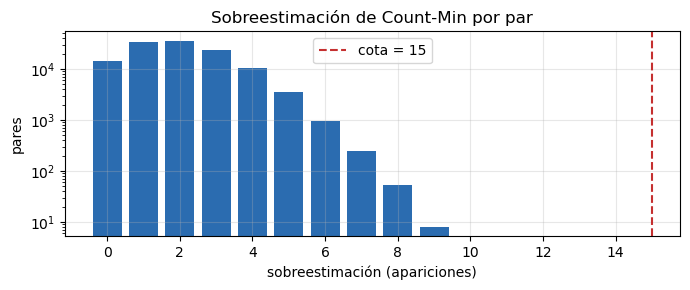

In [10]:
def metricas(conteos, eps_l):
    e = conteos["error"]
    hh_real = set(conteos.loc[conteos["exacto"] >= UMBRAL_HH, "par"])
    hh_est = set(conteos.loc[conteos["estimado"] >= UMBRAL_HH, "par"])
    return {"error_medio": e.mean(), "error_max": int(e.max()), "pct_exactos": 100 * (e == 0).mean(),
            "pct_dentro_cota": 100 * (e <= eps_l).mean(),
            "error_rel_hh": (e / conteos["exacto"])[conteos["exacto"] >= UMBRAL_HH].mean(),
            "hh_precision": len(hh_real & hh_est) / max(len(hh_est), 1),
            "hh_recall": len(hh_real & hh_est) / max(len(hh_real), 1)}

met = metricas(conteos, E_MAX)
print(f"Error medio: {met['error_medio']:.3f} apariciones | máx {met['error_max']} | "
      f"pares exactos {met['pct_exactos']:.1f}%")
print(f"Dentro de la cota de {E_MAX} apariciones: {met['pct_dentro_cota']:.2f}% de los pares (garantía ≥ {100 * (1 - DELTA):.0f}%)")
print(f"Heavy hitters (≥{UMBRAL_HH}): precisión {met['hh_precision']:.3f} | recall {met['hh_recall']:.3f} | "
      f"error relativo medio {100 * met['error_rel_hh']:.2f}%")

plt.figure(figsize=(7, 3))
vc = conteos["error"].value_counts().sort_index()
plt.bar(vc.index, vc.values, color="#2b6cb0")
plt.axvline(E_MAX, color="#c53030", linestyle="--", label=f"cota = {E_MAX}")
plt.yscale("log"); plt.xlabel("sobreestimación (apariciones)"); plt.ylabel("pares"); plt.legend()
plt.title("Sobreestimación de Count-Min por par")
mostrar_fig("error_cms")
error_dist = vc.rename_axis("sobreestimacion").reset_index(name="pares")

- Sobreestimación media de 2.0 apariciones, con máximo de 9

- 11.7% de los pares se estima exacto

- 100% de los pares queda dentro de la cota de 15 apariciones

- Mayoría de pares aparece una sola vez 

- Sobreestimar en 2 un par de 1 aparición es un error relativo grande

#### b. Heavy hitters

Pares con ≥ 50 apariciones: candidatos con Count-min Sketch vs la realidad

In [11]:
hs_flujo = [hashes(x) for x in pares]
cms_cons, _, _ = simular(hs_flujo, w, d, conservador=True)
conteos["estimado_conservador"] = [cms_cons.estimar(*h) for h in hs_claves]

postor = (flujo_pd.assign(par=pares).groupby("par")["postor_unico"].mean() * 100).round(1)
heavy_hitters = (conteos.sort_values("exacto", ascending=False).head(20)
                 .assign(detectado_en_linea=lambda x: x["par"].isin(candidatos),
                         pct_postor_unico=lambda x: x["par"].map(postor))
                 [["par", "exacto", "estimado", "estimado_conservador", "detectado_en_linea", "pct_postor_unico"]]
                 .reset_index(drop=True))

reales = set(conteos.loc[conteos["exacto"] >= UMBRAL_HH, "par"])
print(f"Heavy hitters reales: {len(reales)} | candidatos en línea: {len(candidatos)} | "
      f"aciertos: {len(reales & candidatos)}")
heavy_hitters

Heavy hitters reales: 16 | candidatos en línea: 18 | aciertos: 16


,par,exacto,estimado,estimado_conservador,detectado_en_linea,pct_postor_unico
0,COMISION DE PROMOCION DEL PERU PARA LA EXPORTA...,155,157,155,True,100.0
1,GOBIERNO REGIONAL DE PUNO SEDE CENTRAL|GRUPO S...,153,154,153,True,0.0
2,COMISION DE PROMOCION DEL PERU PARA LA EXPORTA...,128,129,128,True,100.0
3,COMISION DE PROMOCION DEL PERU PARA LA EXPORTA...,113,113,113,True,100.0
4,SEGURO SOCIAL DE SALUD|CARDIO PERFUSION E.I.R...,73,75,73,True,30.1
5,SEGURO SOCIAL DE SALUD|DIAGNOSTICA PERUANA S....,62,67,62,True,3.2
6,GOBIERNO REGIONAL DE MADRE DE DIOS SEDE CENTRA...,58,59,58,True,0.0
7,MTC-PROYECTO ESPECIAL DE INFRAESTRUCTURA DE TR...,57,59,57,True,100.0
8,SEGURO SOCIAL DE SALUD|CYMED MEDICAL SAC,57,59,57,True,47.4
9,CENTRO NACIONAL DE ABASTECIMIENTO DE RECURSOS ...,57,59,57,True,1.8


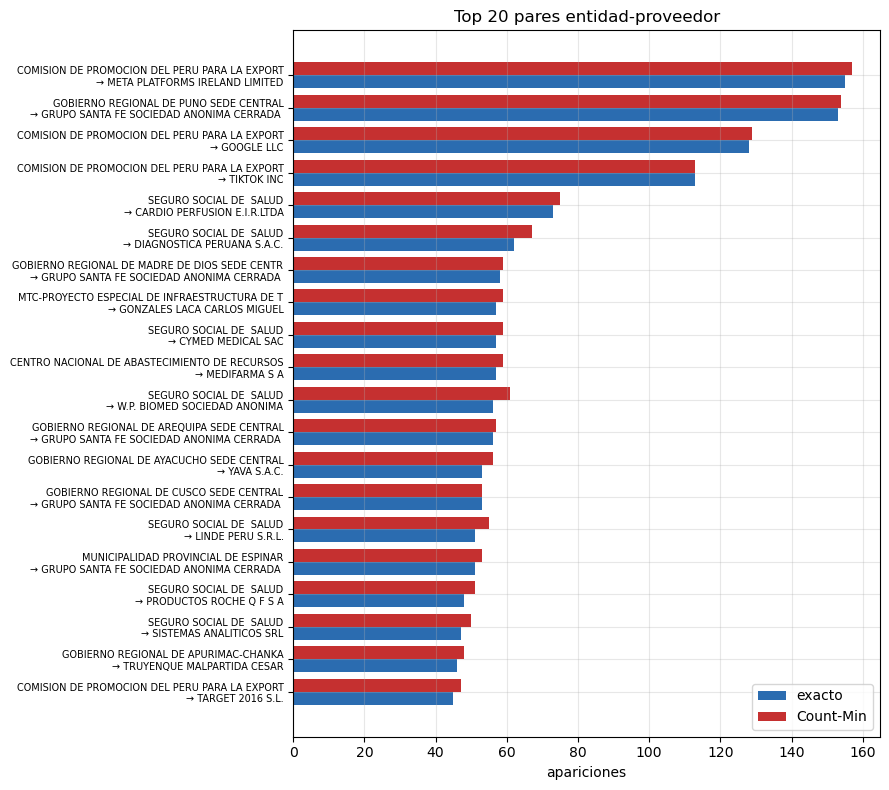

In [12]:
top = heavy_hitters.iloc[::-1]
partes = top["par"].str.split("|", n=1, expand=True)
etiquetas = partes[0].str.slice(0, 45) + "\n→ " + partes[1].str.slice(0, 40)
y = np.arange(len(top))
plt.figure(figsize=(9, 8))
plt.barh(y - 0.2, top["exacto"], height=0.4, color="#2b6cb0", label="exacto")
plt.barh(y + 0.2, top["estimado"], height=0.4, color="#c53030", label="Count-Min")
plt.yticks(y, etiquetas, fontsize=7); plt.xlabel("apariciones"); plt.legend()
plt.title("Top 20 pares entidad-proveedor")
mostrar_fig("heavy_hitters")

- 16 heavy hitters reales, pero se reportan 18 (2 falsos positivos)

- Top: PROMPERÚ - Meta (155), GORE Puno - Grupo Santa Fe (153), PROMPERÚ - Google (128) y PROMPERÚ - TikTok (113)

- 10 de los 16 tienen ≤ 8% de postor único (p.ej. Grupo Santa Fe, 0%)

- 4 tienen 100%: PROMPERÚ con plataformas digitales y PROVIAS por Contratación Directa

### 5. Precisión, memoria y tiempo

- Grilla `w` × `d`, con los hashes precalculados

In [13]:
filas, estimados_config = [], {}
for w_ in [1_024, 4_096, 16_384, w, 65_536]:
    for d_ in [1, 2, 3, 5, 7]:
        for cons in ([False, True] if d_ == d else [False]):
            cms_, _, seg_ = simular(hs_flujo, w_, d_, conservador=cons)
            c_ = conteos[["par", "exacto"]].assign(estimado=[cms_.estimar(*h) for h in hs_claves])
            c_["error"] = c_["estimado"] - c_["exacto"]
            estimados_config[(w_, d_, cons)] = c_["estimado"].to_numpy()
            filas.append({"w": w_, "d": d_, "conservador": cons, "memoria_kb": cms_.memoria_bytes() / 1024,
                          **metricas(c_, math.e / w_ * L), "us_por_llegada": 1e6 * seg_ / L})

tradeoff = pd.DataFrame(filas)
tradeoff.round(4)

,w,d,conservador,memoria_kb,error_medio,error_max,pct_exactos,pct_dentro_cota,error_rel_hh,hh_precision,hh_recall,us_por_llegada
0,1024,1,False,4.0000,179.9419,374,0.0000,100.0000,2.7333,0.0001,1.0,1.0878
1,1024,2,False,8.0000,166.2338,304,0.0000,100.0000,2.5894,0.0001,1.0,1.2337
2,1024,3,False,12.0000,160.2186,304,0.0000,100.0000,2.4707,0.0001,1.0,1.4928
3,1024,5,False,20.0000,153.6952,304,0.0000,100.0000,2.4086,0.0001,1.0,1.7424
4,1024,5,True,20.0000,71.9464,129,0.0016,100.0000,0.2611,0.0001,1.0,1.8240
5,1024,7,False,28.0000,150.1006,294,0.0000,100.0000,2.3898,0.0001,1.0,2.0086
6,4096,1,False,16.0000,44.9762,194,0.0000,99.9112,0.6446,0.0004,1.0,0.9684
7,4096,2,False,32.0000,38.4597,105,0.0000,100.0000,0.5667,0.0011,1.0,1.1576
8,4096,3,False,48.0000,35.6827,75,0.0000,100.0000,0.5237,0.0030,1.0,1.3403
9,4096,5,False,80.0000,32.7766,68,0.0000,100.0000,0.4990,0.0189,1.0,1.7030


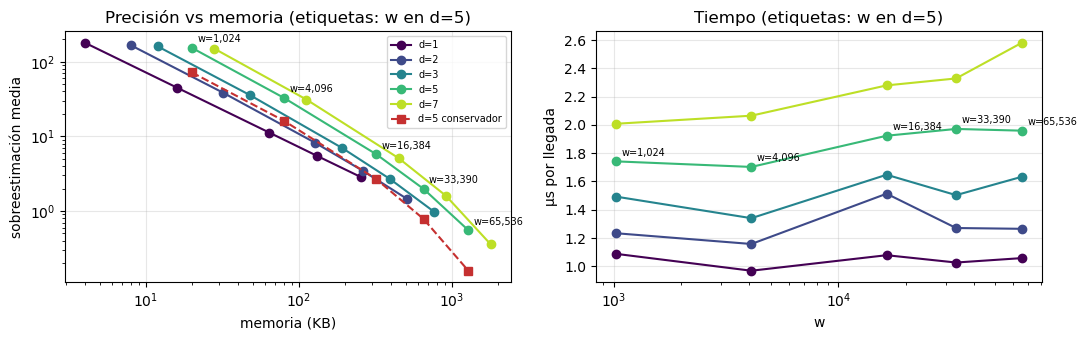

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
clasico = tradeoff[~tradeoff["conservador"]]
colores = plt.cm.viridis(np.linspace(0, .9, clasico["d"].nunique()))
for (d_, g), col in zip(clasico.groupby("d"), colores):
    ax[0].plot(g["memoria_kb"], g["error_medio"], marker="o", color=col, label=f"d={d_}")
    ax[1].plot(g["w"], g["us_por_llegada"], marker="o", color=col, label=f"d={d_}")
for _, f in clasico[clasico["d"] == d].iterrows():
    etiqueta = f"w={int(f['w']):,}"
    ax[0].annotate(etiqueta, (f["memoria_kb"], f["error_medio"]), fontsize=7, color="black", xytext=(4, 4), textcoords="offset points")
    ax[1].annotate(etiqueta, (f["w"], f["us_por_llegada"]), fontsize=7, color="black", xytext=(4, 4), textcoords="offset points")
cons = tradeoff[tradeoff["conservador"]]
ax[0].plot(cons["memoria_kb"], cons["error_medio"], marker="s", color="#c53030", linestyle="--", label=f"d={d} conservador")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("memoria (KB)"); ax[0].set_ylabel("sobreestimación media"); ax[0].set_title(f"Precisión vs memoria (etiquetas: w en d={d})")
ax[0].legend(fontsize=7)
ax[1].set_xscale("log"); ax[1].set_xlabel("w"); ax[1].set_ylabel("µs por llegada"); ax[1].set_title(f"Tiempo (etiquetas: w en d={d})")
mostrar_fig("tradeoff_cms")

- Más columnas `w` → menos error: de 154 apariciones (w=1,024) a 0.55 (w=65,536)

- Más filas `d` también ayudan, pero cada vez menos, y hacen más lento el sketch

- Con `w` chico aparecen miles de falsos heavy hitters

- *Conservative update* reduce el error ~2.5x con la misma memoria

- 652 KB vs 21.1 MB del conteo exacto (33x menos)

### 6. Variación de parámetros

Se mide como varían los resultados según `w` y `d`

In [15]:
claves_np = conteos["par"].to_numpy()
pu_par = conteos["par"].map(postor).to_numpy(dtype=float)
top20_real = set(heavy_hitters["par"])
hh_real = conteos["exacto"].to_numpy() >= UMBRAL_HH

filas = []
for (w_, d_, cons), est_ in estimados_config.items():
    reportados = est_ >= UMBRAL_HH
    top20 = set(claves_np[np.argsort(-est_, kind="stable")[:20]])
    filas.append({"w": w_, "d": d_, "conservador": cons,
                  "hh_reportados": int(reportados.sum()), "hh_falsos": int((reportados & ~hh_real).sum()),
                  "top20_coinciden": len(top20 & top20_real), "estimado_top1": int(est_.max()),
                  "pct_postor_unico_hh": np.nanmean(pu_par[reportados])})

variacion = pd.DataFrame(filas)
variacion["hh_reales"], variacion["pct_postor_unico_hh_real"] = int(hh_real.sum()), np.nanmean(pu_par[hh_real])
print(f"Exacto: {hh_real.sum()} heavy hitters | top 1 = {conteos['exacto'].max()} | "
      f"% postor único promedio de los heavy hitters {np.nanmean(pu_par[hh_real]):.1f}%")
variacion.round(2)

Exacto: 16 heavy hitters | top 1 = 155 | % postor único promedio de los heavy hitters 31.0%


,w,d,conservador,hh_reportados,hh_falsos,top20_coinciden,estimado_top1,pct_postor_unico_hh,hh_reales,pct_postor_unico_hh_real
0,1024,1,False,123871,123855,1,375,11.87,16,31.0
1,1024,2,False,123871,123855,6,344,11.87,16,31.0
2,1024,3,False,123871,123855,7,344,11.87,16,31.0
3,1024,5,False,123871,123855,15,331,11.87,16,31.0
4,1024,5,True,123871,123855,6,155,11.87,16,31.0
5,1024,7,False,123871,123855,14,331,11.87,16,31.0
6,4096,1,False,41793,41777,1,195,12.15,16,31.0
7,4096,2,False,14603,14587,10,191,12.74,16,31.0
8,4096,3,False,5306,5290,16,191,12.95,16,31.0
9,4096,5,False,846,830,18,191,14.70,16,31.0


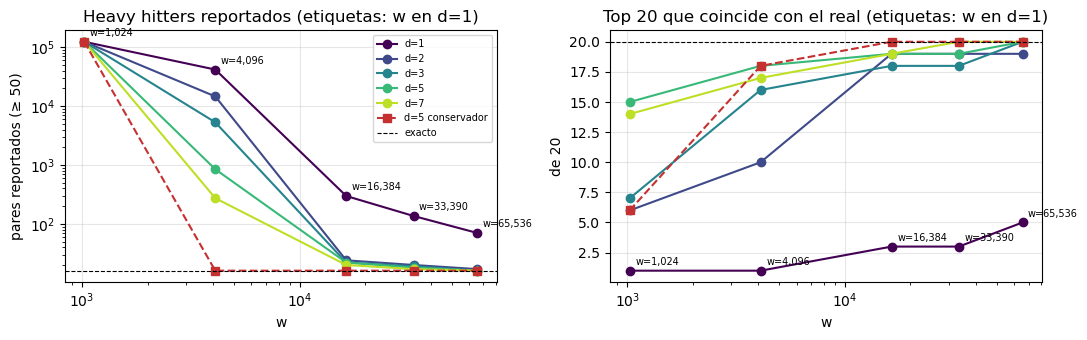

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
clasico = variacion[~variacion["conservador"]]
colores = plt.cm.viridis(np.linspace(0, .9, clasico["d"].nunique()))
for (d_, g), col in zip(clasico.groupby("d"), colores):
    ax[0].plot(g["w"], g["hh_reportados"], marker="o", color=col, label=f"d={d_}")
    ax[1].plot(g["w"], g["top20_coinciden"], marker="o", color=col, label=f"d={d_}")
for _, f in clasico[clasico["d"] == 1].iterrows():
    etiqueta = f"w={int(f['w']):,}"
    ax[0].annotate(etiqueta, (f["w"], f["hh_reportados"]), fontsize=7, color="black", xytext=(4, 4), textcoords="offset points")
    ax[1].annotate(etiqueta, (f["w"], f["top20_coinciden"]), fontsize=7, color="black", xytext=(4, 4), textcoords="offset points")
cons = variacion[variacion["conservador"]]
ax[0].plot(cons["w"], cons["hh_reportados"], marker="s", color="#c53030", linestyle="--", label=f"d={d} conservador")
ax[1].plot(cons["w"], cons["top20_coinciden"], marker="s", color="#c53030", linestyle="--", label=f"d={d} conservador")
ax[0].axhline(hh_real.sum(), color="black", linestyle="--", linewidth=.8, label="exacto")
ax[1].axhline(20, color="black", linestyle="--", linewidth=.8)
ax[0].set_xscale("log"); ax[0].set_yscale("log"); ax[0].set_xlabel("w"); ax[0].set_ylabel("pares reportados (≥ 50)")
ax[0].set_title("Heavy hitters reportados (etiquetas: w en d=1)"); ax[0].legend(fontsize=7)
ax[1].set_xscale("log"); ax[1].set_xlabel("w"); ax[1].set_ylabel("de 20"); ax[1].set_title("Top 20 que coincide con el real (etiquetas: w en d=1)")
mostrar_fig("variacion_cms")

- Con `w` chico, todos los pares parecen heavy hitters

- Con una sola fila (`d=1`) también aparecen muchos falsos (120 con el `w` elegido)

- *Conservative update* con w=4,096 (80 KB) ya acierta los 16, con 8x menos memoria

### 7. Escritura de resultados

Tablas en `temp/c_sketch/tablas/` y `temp/c_sketch/web/`

In [17]:
resumen = pd.DataFrame([{
    "estructura": "Count-Min Sketch", "tarea": "frecuencia de pares entidad-proveedor", "parametros": f"w={w}, d={d}",
    "metrica_error": "sobreestimación media (apariciones)", "error": float(met["error_medio"]),
    "memoria_bytes": float(cms.memoria_bytes()), "memoria_exacta_bytes": float(mem_exacta),
    "us_por_elemento": 1e6 * seg_cms / L, "us_por_elemento_exacto": 1e6 * seg_exacto / L}])

tablas = {"error_dist": error_dist, "heavy_hitters": heavy_hitters, "tradeoff": tradeoff,
          "variacion": variacion, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/c_sketch/: {', '.join(escritos)}")

Escrito en temp/c_sketch/: error_dist, heavy_hitters, tradeoff, variacion, resumen


#### a. Verificación

In [18]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 5 tablas (parquet + json) | 4 figuras: error_cms, heavy_hitters, tradeoff_cms, variacion_cms


---
### 8. Cerrar sesión

In [19]:
spark.stop()